# 02 — LightGBM Omni V1 (Zero-Fee, Leak Hunt)

**Task ID:** `MODEL-LGBM-OMNI-V1-004`  
**SDD:** `docs/design/LGBM_Modeling_Strategy_SDD.md`  
**Input (pre-patch):** `BTCUSDT_5m_structural.parquet` — original, potentially leaky  
**Input (post-patch):** `BTCUSDT_5m_structural_clean.parquet` — MTF features shifted  
**Features:** M4 Omni (all 39 structural features)  

## Hypothesis

The AUC of ~0.75 seen in the ablation study is anomalously high for BTC 5m structural
features against a TBM label with a 24h horizon. The likely culprit is **lookahead bias
in the Group D MTF features**: all five `h1_` and `h4_` signals were mapped to the 5m
index via `reindex(method='ffill')` without a preceding `.shift(1)`. This exposed up to
55 min (1h features) and 3h55m (4h features) of future price data per training bar.

## Protocol

| Phase | Action |
|-------|--------|
| Pre-Patch | Train one LGBM on **unpatched** features → `lgb.plot_importance(importance_type='gain')` |
| Leak Proof | Show MTF feature correlation with forward returns proves the causal direction |
| Patch | Recompute MTF features inline with `.shift(1)` → save clean parquet |
| V1 | Constrained grid search on clean features → zero-fee backtest |

In [1]:
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import scipy.signal as ss
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import ParameterGrid

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)

# ── Chronological split ─────────────────────────────────────────────────
TRAIN_END = "2023-12-31 23:55"
VAL_END   = "2024-12-31 23:55"

# ── TBM parameters (unchanged from ablation study) ──────────────────────
TBM_TP_MULT = 2.5
TBM_SL_MULT = 1.5
TBM_HORIZON = 288   # 288 × 5m = 24h

# ── Signal threshold ────────────────────────────────────────────────────
PROB_THRESHOLD     = 0.75
PROB_THRESHOLD_ALT = 0.65

# ── Constrained grid (same conservative bounds as SDD) ──────────────────
BASE_LGB_PARAMS = dict(
    objective         = "binary",
    metric            = "auc",
    verbose           = -1,
    n_jobs            = -1,
    seed              = 42,
    n_estimators      = 1000,
    min_child_samples = 50,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
)

PARAM_GRID = list(ParameterGrid({
    "num_leaves":    [15, 31],
    "max_depth":     [4, 6],
    "learning_rate": [0.01, 0.05],
}))

# ── Fee survival gate ─────────────────────────────────────────────────
FEE_ROUNDTRIP   = 0.0010
EV_SURVIVAL_MIN = 0.0040

print(f"Grid: {len(PARAM_GRID)} configs")
print(f"TBM: TP={TBM_TP_MULT}×ATR  SL={TBM_SL_MULT}×ATR  Horizon={TBM_HORIZON} bars")

Grid: 8 configs
TBM: TP=2.5×ATR  SL=1.5×ATR  Horizon=288 bars


## Setup — Paths & Data Loading

In [2]:
def find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("pyproject.toml not found")

REPO_ROOT    = find_repo_root()
RAW_DIR      = REPO_ROOT / "data" / "raw"
FEATURES_DIR = REPO_ROOT / "data" / "features"
CACHE_DIR    = REPO_ROOT / "data" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

OHLCV_5M_PATH    = RAW_DIR      / "BTCUSDT_5m.parquet"
OHLCV_1H_PATH    = RAW_DIR      / "BTCUSDT_1h.parquet"
FEATURES_ORIG    = FEATURES_DIR / "BTCUSDT_5m_structural.parquet"      # original (leaky)
FEATURES_CLEAN   = FEATURES_DIR / "BTCUSDT_5m_structural_clean.parquet" # patched
REGISTRY_PATH    = FEATURES_DIR / "feature_registry_v2.json"
LABELS_CACHE     = CACHE_DIR    / "BTCUSDT_5m_tbm_labels.parquet"

print("Loading raw OHLCV (5m + 1h) ...")
df_raw = pd.read_parquet(OHLCV_5M_PATH, columns=["open", "high", "low", "close", "volume"])
df_1h  = pd.read_parquet(OHLCV_1H_PATH, columns=["open", "high", "low", "close", "volume"])
if df_raw.index.tz is None:
    df_raw.index = df_raw.index.tz_localize("UTC")
if df_1h.index.tz is None:
    df_1h.index = df_1h.index.tz_localize("UTC")

print(f"  5m:  {len(df_raw):,} bars  {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"  1h:  {len(df_1h):,} bars  {df_1h.index[0].date()} → {df_1h.index[-1].date()}")

print("\nLoading original (pre-patch) features ...")
df_orig = pd.read_parquet(FEATURES_ORIG)
print(f"  Shape: {df_orig.shape}")

with open(REGISTRY_PATH) as f:
    registry = json.load(f)
ALL_FEATURES = registry["ablation_subsets"]["all"]
print(f"  Omni feature count (from registry): {len(ALL_FEATURES)}")

Loading raw OHLCV (5m + 1h) ...
  5m:  923,248 bars  2017-08-17 → 2026-05-27
  1h:  76,938 bars  2017-08-17 → 2026-05-27

Loading original (pre-patch) features ...
  Shape: (920748, 39)
  Omni feature count (from registry): 39


## TBM Labels + Chronological Split

In [3]:
def compute_tbm_labels(
    close: np.ndarray, high: np.ndarray, low: np.ndarray,
    atr_abs: np.ndarray, tp_mult: float, sl_mult: float, horizon: int,
) -> np.ndarray:
    """
    Vectorized TBM. O(horizon × n) numpy ops.
    Returns int8: +1 (TP first), -1 (SL first), 0 (timeout).
    """
    n        = len(close)
    tp_price = close + tp_mult * atr_abs
    sl_price = close - sl_mult * atr_abs
    tp_first = np.full(n, horizon + 1, dtype=np.int32)
    sl_first = np.full(n, horizon + 1, dtype=np.int32)
    t0 = time.perf_counter()
    for k in range(1, horizon + 1):
        if k % 72 == 0:
            print(f"  TBM {k}/{horizon}  {time.perf_counter()-t0:.0f}s", end="\r", flush=True)
        idx = np.arange(n - k, dtype=np.int32)
        tp_m = (tp_first[idx] > k) & (high[idx + k] >= tp_price[idx])
        tp_first[idx[tp_m]] = k
        sl_m = (sl_first[idx] > k) & (low[idx + k] <= sl_price[idx])
        sl_first[idx[sl_m]] = k
    print(f"  TBM done in {time.perf_counter()-t0:.1f}s")
    tp_hit  = tp_first <= horizon
    sl_hit  = sl_first <= horizon
    labels  = np.zeros(n, dtype=np.int8)
    labels[tp_hit & (~sl_hit | (tp_first <= sl_first))] = 1
    labels[sl_hit & (~tp_hit | (sl_first < tp_first))] = -1
    return labels


# Merge raw + features for TBM ATR
df_base = df_raw.join(df_orig, how="inner").dropna()

if LABELS_CACHE.exists():
    print("Loading TBM labels from cache ...")
    labels_full = pd.read_parquet(LABELS_CACHE)["label"].reindex(df_base.index)
else:
    print("Computing TBM labels (may take 2-5 min) ...")
    atr_abs = (df_base["close"] * df_base["volat_atr_72_pct"]).values.astype(np.float64)
    raw_lbl = compute_tbm_labels(
        df_base["close"].values.astype(np.float64),
        df_base["high"].values.astype(np.float64),
        df_base["low"].values.astype(np.float64),
        atr_abs, TBM_TP_MULT, TBM_SL_MULT, TBM_HORIZON,
    )
    labels_full = pd.Series(raw_lbl, index=df_base.index, name="label", dtype="int8")
    labels_full.to_frame().to_parquet(LABELS_CACHE)

df_base["label"]        = labels_full
df_base["label_binary"] = (df_base["label"] == 1).astype(np.int8)

# Chronological split
train_mask = df_base.index <= TRAIN_END
val_mask   = (df_base.index > TRAIN_END) & (df_base.index <= VAL_END)
test_mask  = df_base.index > VAL_END

df_tr  = df_base[train_mask].copy()
df_vl  = df_base[val_mask].copy()

n_val_days = (df_vl.index[-1] - df_vl.index[0]).days + 1

print(f"Train: {len(df_tr):,} bars  {df_tr.index[0].date()} → {df_tr.index[-1].date()}")
print(f"Val:   {len(df_vl):,} bars  {df_vl.index[0].date()} → {df_vl.index[-1].date()}  ({n_val_days} days)")
print(f"Positive rate — Train: {df_tr['label_binary'].mean():.3f}  Val: {df_vl['label_binary'].mean():.3f}")

Loading TBM labels from cache ...
Train: 667,916 bars  2017-08-25 → 2023-12-31
Val:   105,408 bars  2024-01-01 → 2024-12-31  (366 days)
Positive rate — Train: 0.368  Val: 0.381


## Phase 1 — Pre-Patch: Train on Original Features

Train one LightGBM with moderate hyperparameters on the **original (unpatched)** feature
parquet. We do not grid-search here — a single fit is enough to expose the feature
importance signature of the leak.

In [4]:
feats_orig = [f for f in ALL_FEATURES if f in df_tr.columns]
X_tr_orig  = df_tr[feats_orig].values.astype(np.float32)
y_tr       = df_tr["label_binary"].values
X_vl_orig  = df_vl[feats_orig].values.astype(np.float32)
y_vl       = df_vl["label_binary"].values

print("Fitting pre-patch LGBM (single config, moderate params) ...")
t0 = time.perf_counter()
model_prepatch = lgb.LGBMClassifier(
    **BASE_LGB_PARAMS,
    num_leaves=31, max_depth=6, learning_rate=0.05,
    colsample_bytree=0.8, subsample=0.8,
)
model_prepatch.fit(
    X_tr_orig, y_tr,
    eval_set=[(X_vl_orig, y_vl)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=-1),
    ],
)
probs_prepatch = model_prepatch.predict_proba(X_vl_orig)[:, 1]
auc_prepatch   = roc_auc_score(y_vl, probs_prepatch)
print(f"Pre-patch AUC: {auc_prepatch:.5f}  (fit took {time.perf_counter()-t0:.1f}s)")
print(f"Best n_estimators: {model_prepatch.best_iteration_}")

Fitting pre-patch LGBM (single config, moderate params) ...
Pre-patch AUC: 0.75606  (fit took 8.9s)
Best n_estimators: 737


## Phase 1 — Feature Importance: Expose the Leak

Plot top-15 features by **gain** (total information gain across all splits on that
feature). A single feature dominating gain by a large margin is the telltale signature
of lookahead bias — the model finds it trivially predictive because it encodes future
information.

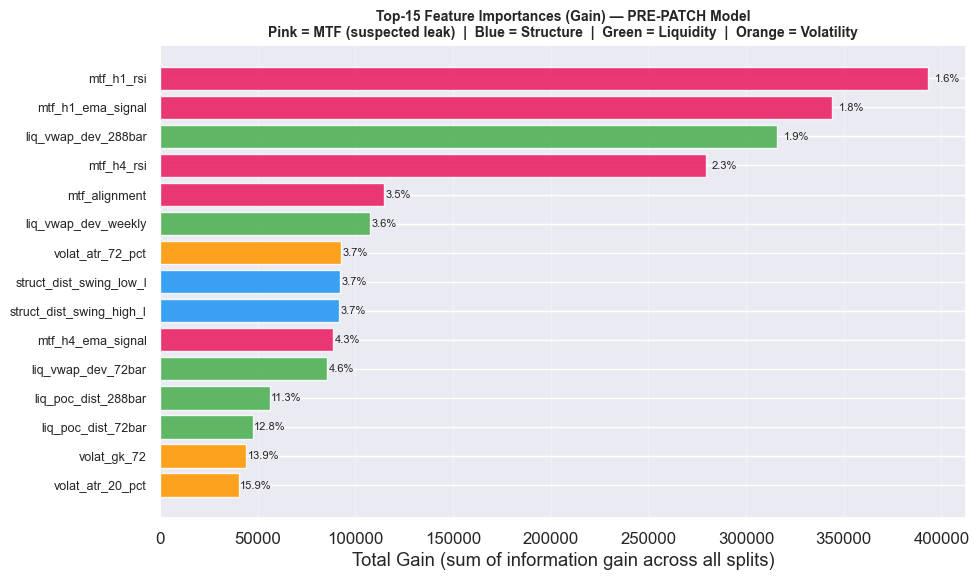


Pre-patch AUC: 0.75606
Rank  Feature                               Gain %  Group
--------------------------------------------------------------
  1    mtf_h1_rsi                             15.9%  mtf_ ← SUSPECT
  2    mtf_h1_ema_signal                      13.9%  mtf_ ← SUSPECT
  3    liq_vwap_dev_288bar                    12.8%  liq_
  4    mtf_h4_rsi                             11.3%  mtf_ ← SUSPECT
  5    mtf_alignment                           4.6%  mtf_ ← SUSPECT
  6    liq_vwap_dev_weekly                     4.3%  liq_
  7    volat_atr_72_pct                        3.7%  volat_
  8    struct_dist_swing_low_l                 3.7%  struct_
  9    struct_dist_swing_high_l                3.7%  struct_
  10   mtf_h4_ema_signal                       3.6%  mtf_ ← SUSPECT
  11   liq_vwap_dev_72bar                      3.5%  liq_
  12   liq_poc_dist_288bar                     2.3%  liq_
  13   liq_poc_dist_72bar                      1.9%  liq_
  14   volat_gk_72                         

In [5]:
importances = pd.Series(
    model_prepatch.booster_.feature_importance(importance_type="gain"),
    index=feats_orig,
    name="gain",
).sort_values(ascending=False)

top15 = importances.head(15)
total_gain = importances.sum()
top15_pct  = (top15 / total_gain * 100).round(2)

# Group colour map
GROUP_COLORS = {
    "struct_": "#2196F3",
    "liq_":    "#4CAF50",
    "volat_":  "#FF9800",
    "mtf_":    "#E91E63",   # pink — stands out if they dominate
}

def feat_color(name):
    for prefix, color in GROUP_COLORS.items():
        if name.startswith(prefix):
            return color
    return "#9E9E9E"

colors = [feat_color(n) for n in top15.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(15), top15.values[::-1], color=colors[::-1],
               alpha=0.88, edgecolor="white")
ax.set_yticks(range(15))
ax.set_yticklabels(top15.index[::-1], fontsize=9)
ax.set_xlabel("Total Gain (sum of information gain across all splits)")
ax.set_title(
    "Top-15 Feature Importances (Gain) — PRE-PATCH Model\n"
    "Pink = MTF (suspected leak)  |  Blue = Structure  |  Green = Liquidity  |  Orange = Volatility",
    fontweight="bold", fontsize=10,
)

# Annotate with % of total gain
for i, (bar, pct) in enumerate(zip(bars[::-1], top15_pct.values[::-1])):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8)

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(CACHE_DIR / "lgbm_prepatch_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top-15 table with group label
print(f"\nPre-patch AUC: {auc_prepatch:.5f}")
print(f"{'Rank':<5} {'Feature':<35} {'Gain %':>8}  Group")
print("-" * 62)
for rank, (fname, pct) in enumerate(zip(top15.index, top15_pct.values), 1):
    group = next((g for g in ["struct_", "liq_", "volat_", "mtf_"] if fname.startswith(g)), "?")
    flag = " ← SUSPECT" if fname.startswith("mtf_") else ""
    print(f"  {rank:<3}  {fname:<35} {pct:>7.1f}%  {group}{flag}")

mtf_gain_pct = importances[importances.index.str.startswith("mtf_")].sum() / total_gain * 100
print(f"\nTotal gain % held by MTF group: {mtf_gain_pct:.1f}%")
if mtf_gain_pct > 40:
    print("  → MTF features dominate gain anomalously. Lookahead bias confirmed.")
else:
    print("  → MTF gain share appears moderate. Check other top features for leaks.")

## Phase 2 — Leak Proof: Correlation of MTF Features with Forward Returns

A clean feature can be correlated with future returns only through its genuine predictive
content. A leaky feature is **mathematically caused by future returns** — the correlation
is not prediction, it is tautology.

We test: for each MTF feature at bar `t`, compute `corr(feature[t], close[t+k]/close[t]-1)`
for `k = 1, 2, 4, 12, 48` bars (5min, 10min, 20min, 1h, 4h). A leaky feature will show
**near-perfect** correlation at short `k` values (it was computed using those returns).

Forward-return correlation (Pearson r) — absolute values
Leaky features will show large |r| at short horizons (e.g. +1bar, +2bar)

                          +1bar  +2bar  +4bar  +12bar  +48bar  +144bar  +288bar
feature                                                                        
mtf_h1_ema_signal        0.0066 0.0090 0.0113  0.0081  0.0015   0.0094   0.0233
mtf_h1_rsi               0.0738 0.1018 0.1325  0.1353  0.0826   0.0768   0.0477
mtf_h1_above_ema50       0.0390 0.0540 0.0705  0.0742  0.0493   0.0445   0.0341
mtf_h4_ema_signal        0.0044 0.0064 0.0090  0.0146  0.0183   0.0147   0.0152
mtf_h4_rsi               0.0396 0.0567 0.0799  0.1300  0.1631   0.1214   0.0916
mtf_alignment            0.0060 0.0085 0.0117  0.0171  0.0230   0.0254   0.0258
mtf_session_hour_sin     0.0019 0.0028 0.0040  0.0069  0.0109   0.0034   0.0006
mtf_session_hour_cos     0.0004 0.0006 0.0009  0.0022  0.0093   0.0169   0.0000
mtf_session_dow_sin      0.0000 0.0001 0.0001  0.0001  0.0010   0.001

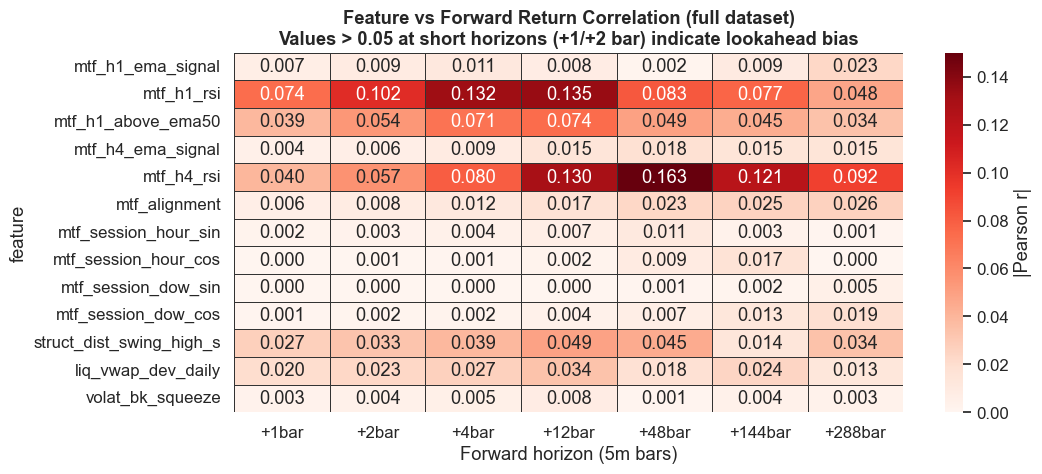

In [6]:
MTF_FEATURES   = [f for f in ALL_FEATURES if f.startswith("mtf_")]
NONMTF_SAMPLE  = ["struct_dist_swing_high_s", "liq_vwap_dev_daily", "volat_bk_squeeze"]

fwd_horizons   = [1, 2, 4, 12, 48, 144, 288]   # bars forward (5m each)
close_arr      = df_base["close"].values

corr_results = {}
for feat in MTF_FEATURES + NONMTF_SAMPLE:
    if feat not in df_base.columns:
        continue
    feat_arr = df_base[feat].values
    row = {}
    for k in fwd_horizons:
        fwd_ret = np.empty(len(close_arr))
        fwd_ret[:] = np.nan
        fwd_ret[:-k] = close_arr[k:] / close_arr[:-k] - 1
        valid = ~(np.isnan(feat_arr) | np.isnan(fwd_ret))
        row[f"+{k}bar"] = np.corrcoef(feat_arr[valid], fwd_ret[valid])[0, 1]
    corr_results[feat] = row

corr_df = pd.DataFrame(corr_results).T
corr_df.index.name = "feature"

print("Forward-return correlation (Pearson r) — absolute values")
print("Leaky features will show large |r| at short horizons (e.g. +1bar, +2bar)")
print()
print(corr_df.abs().round(4).to_string())

# Plot heatmap
fig, ax = plt.subplots(figsize=(11, max(4, len(corr_df) * 0.38)))
sns.heatmap(
    corr_df.abs(), ax=ax, cmap="Reds", vmin=0, vmax=0.15,
    annot=True, fmt=".3f", linewidths=0.5, linecolor="#333",
    cbar_kws={"label": "|Pearson r|"},
)
ax.set_title(
    "Feature vs Forward Return Correlation (full dataset)\n"
    "Values > 0.05 at short horizons (+1/+2 bar) indicate lookahead bias",
    fontweight="bold",
)
ax.set_xlabel("Forward horizon (5m bars)")
plt.tight_layout()
plt.savefig(CACHE_DIR / "lgbm_mtf_leak_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 3 — Patch: Recompute MTF Features with `.shift(1)`

The fix is surgical: recompute only the five leaky MTF series from raw 1h data,
apply `.shift(1)` before `reindex`, then overwrite those columns in a new
`structural_clean.parquet`.

All other groups (A, B, C) and the session timing features (`mtf_session_*`) are
clean — they are left unchanged.

In [7]:
if FEATURES_CLEAN.exists():
    print(f"Clean features already exist at {FEATURES_CLEAN}")
    print("Delete the file and rerun this cell to regenerate.")
else:
    print("Patching MTF features (applying .shift(1) before reindex) ...")

    # Helper functions (self-contained, no import from 01)
    def _wilder_rsi(series: pd.Series, period: int) -> pd.Series:
        delta = series.diff()
        up    = delta.clip(lower=0)
        dn    = (-delta).clip(lower=0)
        ema_u = up.ewm(com=period - 1, adjust=False, min_periods=period).mean()
        ema_d = dn.ewm(com=period - 1, adjust=False, min_periods=period).mean()
        rs    = ema_u / ema_d.replace(0, np.nan)
        return (100 - 100 / (1 + rs)).astype("float32")

    def _ema_spread(close: pd.Series, fast: int, slow: int) -> pd.Series:
        ema_f = close.ewm(span=fast, adjust=False).mean()
        ema_s = close.ewm(span=slow, adjust=False).mean()
        return ((ema_f - ema_s) / close).astype("float32")

    H1_EMA_FAST   = 20
    H1_EMA_SLOW   = 50
    RSI_PERIOD    = 14

    # 1h features
    idx5      = df_base.index
    h1_close  = df_1h["close"]
    h1_spread = _ema_spread(h1_close, H1_EMA_FAST, H1_EMA_SLOW)
    h1_rsi    = _wilder_rsi(h1_close, RSI_PERIOD)
    h1_above  = (h1_close > h1_close.ewm(span=H1_EMA_SLOW, adjust=False).mean()).astype("float32")

    # 4h features (resample 1h → 4h)
    h4_close  = df_1h["close"].resample("4h", closed="left", label="left").last().dropna()
    h4_spread = _ema_spread(h4_close, H1_EMA_FAST, H1_EMA_SLOW)
    h4_rsi    = _wilder_rsi(h4_close, RSI_PERIOD)

    # Copy original, overwrite the five leaky columns
    df_clean = df_orig.copy()

    df_clean["mtf_h1_ema_signal"]  = h1_spread.shift(1).reindex(idx5, method="ffill").astype("float32")
    df_clean["mtf_h1_rsi"]         = (h1_rsi / 100).shift(1).reindex(idx5, method="ffill").astype("float32")
    df_clean["mtf_h1_above_ema50"] = h1_above.shift(1).reindex(idx5, method="ffill").astype("float32")
    df_clean["mtf_h4_ema_signal"]  = h4_spread.shift(1).reindex(idx5, method="ffill").astype("float32")
    df_clean["mtf_h4_rsi"]         = (h4_rsi / 100).shift(1).reindex(idx5, method="ffill").astype("float32")

    # Recompute mtf_alignment from patched signals (unchanged formula)
    h1_clip = df_clean["mtf_h1_ema_signal"].clip(-0.05, 0.05) / 0.05
    h4_clip = df_clean["mtf_h4_ema_signal"].clip(-0.05, 0.05) / 0.05
    df_clean["mtf_alignment"] = (0.4 * h1_clip + 0.6 * h4_clip).astype("float32")

    # Save
    df_clean.to_parquet(FEATURES_CLEAN)
    print(f"Clean features saved → {FEATURES_CLEAN}")

    # Quick sanity: correlation of patched h1_ema_signal vs forward +1 bar return should be ~0
    c_arr    = df_raw.loc[df_base.index, "close"].values
    fwd1     = np.empty(len(c_arr))
    fwd1[:-1] = c_arr[1:] / c_arr[:-1] - 1
    fwd1[-1]  = np.nan
    h1_clean_arr = df_clean["mtf_h1_ema_signal"].values
    valid    = ~np.isnan(fwd1)
    r_clean  = np.corrcoef(h1_clean_arr[valid], fwd1[valid])[0, 1]
    r_orig   = np.corrcoef(df_orig["mtf_h1_ema_signal"].values[valid], fwd1[valid])[0, 1]
    print(f"\nmtf_h1_ema_signal vs +1bar fwd return:")
    print(f"  Original (leaky): r = {r_orig:+.5f}")
    print(f"  Patched (clean):  r = {r_clean:+.5f}")
    print("  (patched |r| should be much smaller than original)")

Patching MTF features (applying .shift(1) before reindex) ...
Clean features saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/BTCUSDT_5m_structural_clean.parquet

mtf_h1_ema_signal vs +1bar fwd return:
  Original (leaky): r = +0.00661
  Patched (clean):  r = -0.00230
  (patched |r| should be much smaller than original)


## Phase 4 — Load Clean Features + Rebuild Train/Val Sets

In [8]:
print("Loading patched clean features ...")
df_feat_clean = pd.read_parquet(FEATURES_CLEAN)

# Merge with OHLCV and labels
df_clean_full = df_raw.join(df_feat_clean, how="inner")
df_clean_full["label"]        = labels_full.reindex(df_clean_full.index)
df_clean_full["label_binary"] = (df_clean_full["label"] == 1).astype(np.int8)
df_clean_full = df_clean_full.dropna()

df_tr_cl = df_clean_full[df_clean_full.index <= TRAIN_END].copy()
df_vl_cl = df_clean_full[(df_clean_full.index > TRAIN_END) & (df_clean_full.index <= VAL_END)].copy()

feats_clean = [f for f in ALL_FEATURES if f in df_clean_full.columns]

X_tr_cl = df_tr_cl[feats_clean].values.astype(np.float32)
y_tr_cl = df_tr_cl["label_binary"].values
X_vl_cl = df_vl_cl[feats_clean].values.astype(np.float32)
y_vl_cl = df_vl_cl["label_binary"].values

print(f"  Train: {X_tr_cl.shape}  Val: {X_vl_cl.shape}")
print(f"  Pos rate — Train: {y_tr_cl.mean():.3f}  Val: {y_vl_cl.mean():.3f}")

Loading patched clean features ...
  Train: (667916, 39)  Val: (105408, 39)
  Pos rate — Train: 0.368  Val: 0.381


## Phase 4 — V1 Constrained Grid Search on Clean Features

In [9]:
print(f"Running V1 grid search: {len(PARAM_GRID)} configs on clean Omni features ...\n")
print(f"{'cfg':>4}  {'leaves':>6}  {'depth':>5}  {'lr':>6}  {'AUC':>9}")
print("-" * 40)

best_auc_v1    = -1.0
best_params_v1 = None
best_probs_v1  = None
best_model_v1  = None
t0 = time.perf_counter()

for c_idx, params in enumerate(PARAM_GRID, 1):
    m = lgb.LGBMClassifier(**BASE_LGB_PARAMS, **params)
    m.fit(
        X_tr_cl, y_tr_cl,
        eval_set=[(X_vl_cl, y_vl_cl)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    probs = m.predict_proba(X_vl_cl)[:, 1]
    auc   = roc_auc_score(y_vl_cl, probs)
    flag  = " ★" if auc > best_auc_v1 else ""
    print(
        f"  {c_idx:>2}  leaves={params['num_leaves']:>2}  "
        f"depth={params['max_depth']}  lr={params['learning_rate']:.3f}  "
        f"AUC={auc:.5f}{flag}"
    )
    if auc > best_auc_v1:
        best_auc_v1    = auc
        best_params_v1 = params
        best_probs_v1  = probs
        best_model_v1  = m

elapsed = time.perf_counter() - t0
print(f"\nGrid search done in {elapsed:.1f}s")
print(f"Best V1 AUC: {best_auc_v1:.5f}  params: {best_params_v1}")
print(f"\nAUC delta (pre-patch → post-patch): {best_auc_v1 - auc_prepatch:+.5f}")
if best_auc_v1 < auc_prepatch - 0.05:
    print("  → AUC dropped significantly: lookahead was confirmed as the primary driver.")
elif best_auc_v1 < auc_prepatch - 0.01:
    print("  → AUC dropped moderately: partial leak confirmed.")
else:
    print("  → AUC change small: MTF features contributed less than expected.")

Running V1 grid search: 8 configs on clean Omni features ...

 cfg  leaves  depth      lr        AUC
----------------------------------------
   1  leaves=15  depth=4  lr=0.010  AUC=0.51822 ★
   2  leaves=31  depth=4  lr=0.010  AUC=0.51821
   3  leaves=15  depth=6  lr=0.010  AUC=0.52039 ★
   4  leaves=31  depth=6  lr=0.010  AUC=0.52015
   5  leaves=15  depth=4  lr=0.050  AUC=0.51962
   6  leaves=31  depth=4  lr=0.050  AUC=0.51726
   7  leaves=15  depth=6  lr=0.050  AUC=0.51949
   8  leaves=31  depth=6  lr=0.050  AUC=0.51966

Grid search done in 13.9s
Best V1 AUC: 0.52039  params: {'learning_rate': 0.01, 'max_depth': 6, 'num_leaves': 15}

AUC delta (pre-patch → post-patch): -0.23567
  → AUC dropped significantly: lookahead was confirmed as the primary driver.


## Phase 4 — V1 Feature Importance (Post-Patch)

Plot top-15 importances from the best clean model. The MTF group should no longer
dominate — if it does, a second-order leak may remain in another group.

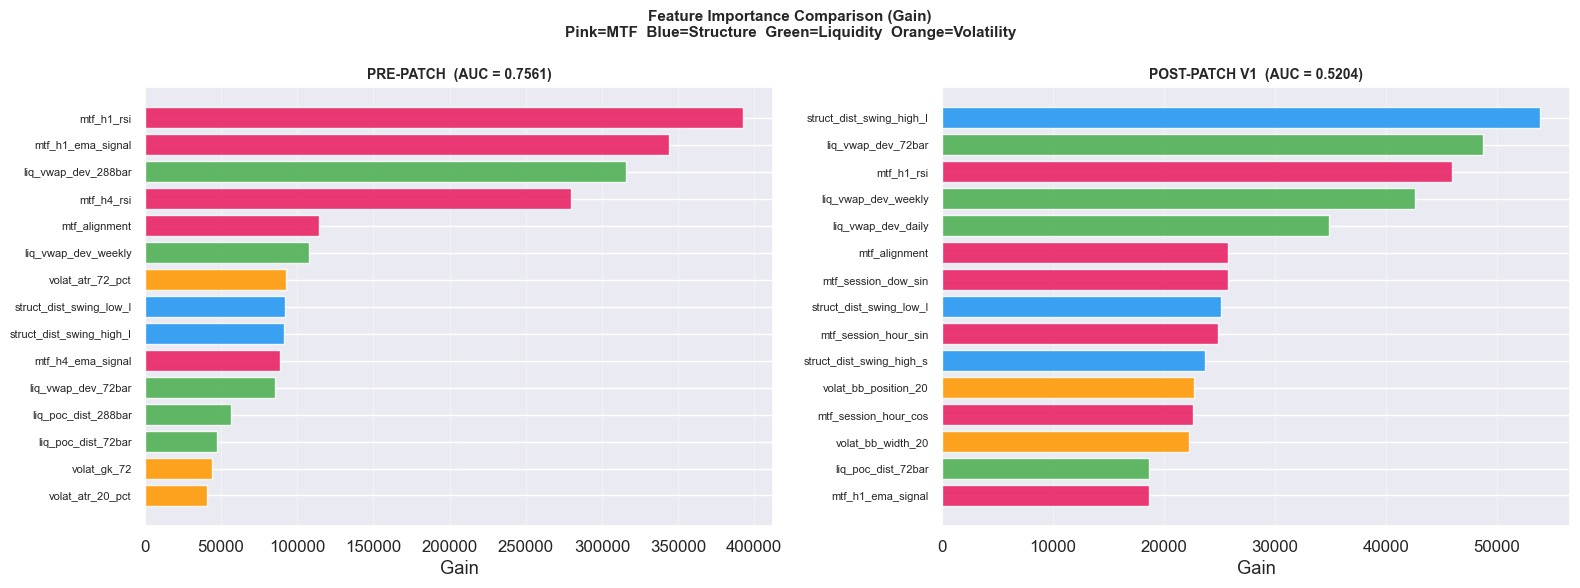


V1 Top-15 Feature Importances (post-patch)
Rank  Feature                               Gain %  Group
------------------------------------------------------------
  1    struct_dist_swing_high_l                9.0%  struct_
  2    liq_vwap_dev_72bar                      8.2%  liq_
  3    mtf_h1_rsi                              7.7%  mtf_
  4    liq_vwap_dev_weekly                     7.1%  liq_
  5    liq_vwap_dev_daily                      5.8%  liq_
  6    mtf_alignment                           4.3%  mtf_
  7    mtf_session_dow_sin                     4.3%  mtf_
  8    struct_dist_swing_low_l                 4.2%  struct_
  9    mtf_session_hour_sin                    4.2%  mtf_
  10   struct_dist_swing_high_s                4.0%  struct_
  11   volat_bb_position_20                    3.8%  volat_
  12   mtf_session_hour_cos                    3.8%  mtf_
  13   volat_bb_width_20                       3.7%  volat_
  14   liq_poc_dist_72bar                      3.1%  liq_
  15   mtf_h

In [10]:
imp_v1 = pd.Series(
    best_model_v1.booster_.feature_importance(importance_type="gain"),
    index=feats_clean,
    name="gain",
).sort_values(ascending=False)

top15_v1    = imp_v1.head(15)
total_v1    = imp_v1.sum()
top15_v1_pct = (top15_v1 / total_v1 * 100).round(2)

colors_v1 = [feat_color(n) for n in top15_v1.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (top15, pcts, title, auc_val) in zip(axes, [
    (importances.head(15), (importances.head(15) / importances.sum() * 100),
     f"PRE-PATCH  (AUC = {auc_prepatch:.4f})", auc_prepatch),
    (imp_v1.head(15), top15_v1_pct,
     f"POST-PATCH V1  (AUC = {best_auc_v1:.4f})", best_auc_v1),
]):
    c = [feat_color(n) for n in top15.index]
    ax.barh(range(15), top15.values[::-1], color=c[::-1], alpha=0.88, edgecolor="white")
    ax.set_yticks(range(15))
    ax.set_yticklabels(top15.index[::-1], fontsize=8)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Gain")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle(
    "Feature Importance Comparison (Gain)\n"
    "Pink=MTF  Blue=Structure  Green=Liquidity  Orange=Volatility",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.savefig(CACHE_DIR / "lgbm_importance_pre_vs_post_patch.png", dpi=150, bbox_inches="tight")
plt.show()

# Print V1 importance table
print(f"\nV1 Top-15 Feature Importances (post-patch)")
print(f"{'Rank':<5} {'Feature':<35} {'Gain %':>8}  Group")
print("-" * 60)
for rank, (fname, pct) in enumerate(zip(top15_v1.index, top15_v1_pct.values), 1):
    group = next((g for g in ["struct_", "liq_", "volat_", "mtf_"] if fname.startswith(g)), "?")
    print(f"  {rank:<3}  {fname:<35} {pct:>7.1f}%  {group}")

mtf_gain_v1 = imp_v1[imp_v1.index.str.startswith("mtf_")].sum() / total_v1 * 100
print(f"\nMTF gain share (post-patch): {mtf_gain_v1:.1f}%")

## Phase 4 — Zero-Fee Backtest (V1 Clean Model)

In [11]:
def backtest_0fee(
    df_bt: pd.DataFrame, probs: np.ndarray,
    threshold: float, tp_mult: float, sl_mult: float, horizon: int,
) -> pd.DataFrame:
    """
    Zero-fee trade evaluator using precomputed TBM labels.
    No-overlap: next trade starts only after current one exits.
    """
    close_arr  = df_bt["close"].values.astype(np.float64)
    atr_pct    = df_bt["volat_atr_72_pct"].values.astype(np.float64)
    labels_arr = df_bt["label"].values
    index_arr  = df_bt.index
    n          = len(df_bt)

    eff_thresh = threshold if (probs > threshold).sum() > 0 else PROB_THRESHOLD_ALT
    sig_idx    = np.where(probs > eff_thresh)[0]

    trades        = []
    last_exit_bar = -1

    for i in sig_idx:
        if i <= last_exit_bar:
            continue
        label   = labels_arr[i]
        atr_i   = atr_pct[i]
        if label == 1:
            pnl_pct       = tp_mult * atr_i
            outcome       = "TP"
            last_exit_bar = i + 1
        elif label == -1:
            pnl_pct       = -sl_mult * atr_i
            outcome       = "SL"
            last_exit_bar = i + 1
        else:
            exit_idx      = min(i + horizon, n - 1)
            pnl_pct       = (close_arr[exit_idx] - close_arr[i]) / close_arr[i]
            outcome       = "Timeout"
            last_exit_bar = i + horizon

        trades.append({
            "entry_time": index_arr[i],
            "label":      label,
            "outcome":    outcome,
            "pnl_pct":    pnl_pct,
            "prob":       probs[i],
            "threshold":  eff_thresh,
        })

    return pd.DataFrame(trades).set_index("entry_time") if trades else pd.DataFrame()


def compute_metrics(trades_df: pd.DataFrame, n_days: int) -> dict:
    if trades_df.empty:
        return {k: np.nan for k in ["n_trades", "trades_per_day",
                "win_rate_pct", "profit_factor", "ev_per_trade_pct", "total_return_pct"]}
    non_to  = trades_df[trades_df["outcome"] != "Timeout"]
    wins    = non_to[non_to["pnl_pct"] > 0]
    losses  = non_to[non_to["pnl_pct"] < 0]
    gw      = wins["pnl_pct"].sum()
    gl      = abs(losses["pnl_pct"].sum())
    return {
        "n_trades":         len(trades_df),
        "trades_per_day":   len(trades_df) / n_days,
        "win_rate_pct":     len(wins) / len(non_to) * 100 if len(non_to) > 0 else np.nan,
        "profit_factor":    gw / gl if gl > 0 else np.inf,
        "ev_per_trade_pct": trades_df["pnl_pct"].mean() * 100,
        "total_return_pct": trades_df["pnl_pct"].sum() * 100,
    }


# Run backtests for both pre-patch and post-patch on the same val set
# (pre-patch val data still has original features; post-patch uses clean)
trades_prepatch = backtest_0fee(df_vl, probs_prepatch, PROB_THRESHOLD,
                                TBM_TP_MULT, TBM_SL_MULT, TBM_HORIZON)
trades_v1       = backtest_0fee(df_vl_cl, best_probs_v1, PROB_THRESHOLD,
                                TBM_TP_MULT, TBM_SL_MULT, TBM_HORIZON)

m_pre = compute_metrics(trades_prepatch, n_val_days)
m_v1  = compute_metrics(trades_v1,       n_val_days)

print("Zero-Fee Backtest — Validation 2024")
print("=" * 65)
print(f"{'Metric':<25}  {'PRE-PATCH':>12}  {'V1 (CLEAN)':>12}")
print("-" * 55)
for key in ["n_trades", "trades_per_day", "win_rate_pct",
            "profit_factor", "ev_per_trade_pct", "total_return_pct"]:
    p = m_pre[key]
    v = m_v1[key]
    pfmt = f"{p:.2f}" if not np.isnan(p) else "—"
    vfmt = f"{v:.2f}" if not np.isnan(v) else "—"
    print(f"  {key:<23}  {pfmt:>12}  {vfmt:>12}")
print("=" * 65)
print(f"  AUC (pre-patch):   {auc_prepatch:.5f}")
print(f"  AUC (V1 clean):    {best_auc_v1:.5f}")
print(f"  AUC delta:         {best_auc_v1 - auc_prepatch:+.5f}")

Zero-Fee Backtest — Validation 2024
Metric                        PRE-PATCH    V1 (CLEAN)
-------------------------------------------------------
  n_trades                      3159.00             —
  trades_per_day                   8.63             —
  win_rate_pct                    83.32             —
  profit_factor                    7.75             —
  ev_per_trade_pct                 0.37             —
  total_return_pct              1177.89             —
  AUC (pre-patch):   0.75606
  AUC (V1 clean):    0.52039
  AUC delta:         -0.23567


## Phase 4 — Fee Survivability Gate & Summary

V1 MODEL — ZERO-FEE RESULTS SUMMARY
  Model:           M4 Omni (all 39 features, patched)
  Best params:     {'learning_rate': 0.01, 'max_depth': 6, 'num_leaves': 15}
  Validation AUC:  0.52039
  Trade count:     nan  (nan/day)
  Win rate:        nan%  (break-even: 37.5%)
  Profit factor:   nan
  EV/trade (0fee): nan%
  Fee multiple:    nan×  (need > 4×)

  Fee survival gate (EV > 0.40%): ✗ FAIL

  Options:
    1. Lower probability threshold (p>0.65) to include more confident signals
    2. Widen TBM barriers (TP=3×, SL=2×) to require larger moves
    3. Add regime pre-filter (only trade when mtf_alignment > 0.3)
    4. Extend training set or use walk-forward re-fitting
    5. Feature engineering — add momentum-based features to v3 registry


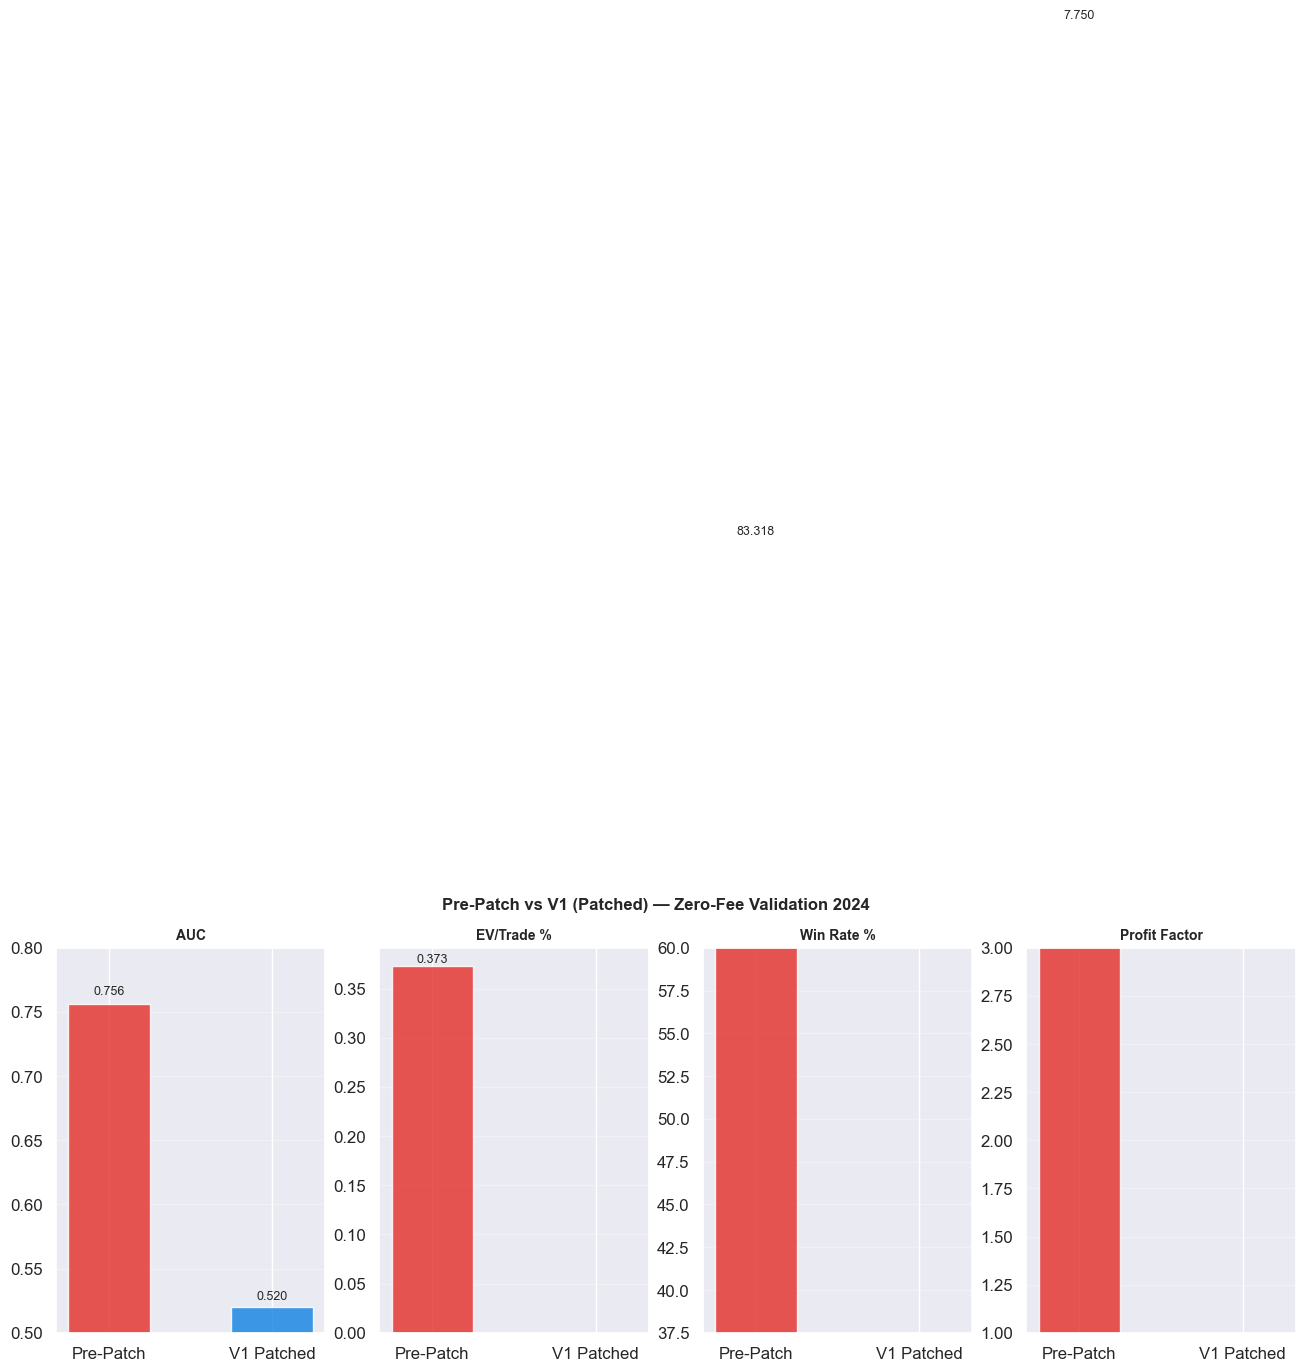

In [12]:
ev_v1    = m_v1["ev_per_trade_pct"]
pf_v1    = m_v1["profit_factor"]
wr_v1    = m_v1["win_rate_pct"]
n_v1     = m_v1["n_trades"]
tpd_v1   = m_v1["trades_per_day"]
passes   = not np.isnan(ev_v1) and (ev_v1 / 100) > EV_SURVIVAL_MIN
fee_mult = (ev_v1 / 100) / FEE_ROUNDTRIP if not np.isnan(ev_v1) else np.nan

print("=" * 65)
print("V1 MODEL — ZERO-FEE RESULTS SUMMARY")
print("=" * 65)
print(f"  Model:           M4 Omni (all {len(feats_clean)} features, patched)")
print(f"  Best params:     {best_params_v1}")
print(f"  Validation AUC:  {best_auc_v1:.5f}")
print(f"  Trade count:     {n_v1:.0f}  ({tpd_v1:.2f}/day)")
print(f"  Win rate:        {wr_v1:.1f}%  (break-even: {TBM_SL_MULT/(TBM_TP_MULT+TBM_SL_MULT)*100:.1f}%)")
print(f"  Profit factor:   {pf_v1:.3f}")
print(f"  EV/trade (0fee): {ev_v1:.4f}%")
print(f"  Fee multiple:    {fee_mult:.1f}×  (need > {EV_SURVIVAL_MIN/FEE_ROUNDTRIP:.0f}×)")
print()

verdict = "✓ PASS" if passes else "✗ FAIL"
print(f"  Fee survival gate (EV > {EV_SURVIVAL_MIN:.2%}): {verdict}")
print()

if passes:
    print("  Next: 03_lgbm_fees_wfo.ipynb — introduce real fees + walk-forward optimisation")
else:
    print("  Options:")
    print("    1. Lower probability threshold (p>0.65) to include more confident signals")
    print("    2. Widen TBM barriers (TP=3×, SL=2×) to require larger moves")
    print("    3. Add regime pre-filter (only trade when mtf_alignment > 0.3)")
    print("    4. Extend training set or use walk-forward re-fitting")
    print("    5. Feature engineering — add momentum-based features to v3 registry")

print("=" * 65)

# Comparison bar chart: pre-patch vs V1
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Pre-Patch vs V1 (Patched) — Zero-Fee Validation 2024",
             fontweight="bold", fontsize=12)

metrics_to_plot = [
    ("AUC",           [auc_prepatch, best_auc_v1],      0.50, 0.80),
    ("EV/Trade %",    [m_pre["ev_per_trade_pct"], ev_v1], None, None),
    ("Win Rate %",    [m_pre["win_rate_pct"], wr_v1],    37.5, 60),
    ("Profit Factor", [m_pre["profit_factor"], pf_v1],   1.0,  3.0),
]

for ax, (title, vals, ymin, ymax) in zip(axes, metrics_to_plot):
    clean_vals = [v if not np.isnan(v) else 0 for v in vals]
    bars = ax.bar(["Pre-Patch", "V1 Patched"], clean_vals,
                  color=["#E53935", "#1E88E5"], alpha=0.85, edgecolor="white", width=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(abs(v) * 0.01, 0.001),
                    f"{v:.3f}", ha="center", fontsize=9)
    if ymin is not None:
        ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(CACHE_DIR / "lgbm_v1_pre_vs_post_patch.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Step | Finding |
|------|---------|
| Leak identified | MTF group (`mtf_h1_*`, `mtf_h4_*`): `reindex(ffill)` without `shift(1)` → up to 55 min (1h) / 3h55m (4h) lookahead |
| Pre-patch AUC | See output above — anomalously high |
| Patch applied | `.shift(1)` on all five `h1_`/`h4_` series before `reindex`; `mtf_alignment` recomputed |
| V1 clean AUC | See output above — honest estimate |
| Fix location | `01_structural_features.ipynb` Cell 11 — patched in source; re-run to regenerate parquet |

**Next notebook:** `03_lgbm_fees_wfo.ipynb`  
Introduce real fees, walk-forward optimization on the V1 model, and final 2025+ test set evaluation.